In [21]:
import os
import io
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# import DeepEye analysis functions
from deepeye_analysis_package.preprocessing import getFixationLatency, handle_carryover_fixations_and_merge, addAOI
from deepeye_analysis_package.plotting import plot2d

### Create dataframe with 1 saccade per trial, filter saccades, normalize to the right and plot

In [22]:
# Get relevant saccades (one per trial)
def getSaccades(df, fn='', plot=False):  
    
    
    ### Get timestamp of when target was presented and add it to the dataframe ###

    # 1) get the first time sample when the target is presented
    sampTime_df = df.drop_duplicates(subset=['trialNr'],  keep='first', ignore_index=True)

    # 2) extract the columns needed
    sampTime_df = sampTime_df[['trialNr', 'sampTime']]

    # 3) rename the columns so they would be added
    sampTime_df.columns = ['trialNr', 'targSampTime']

    # 4) Get only fixations start and end events ###
    fix_events_df = df[df['FixStartEnd'].isin(['fix_start', 'fix_end'])]

    # 5) Merge the target time into the fix_events_df (one time per trial)
    fix_events_df = pd.merge(fix_events_df, sampTime_df, on="trialNr")

    ### Convert to cm ###
    # Convert coordinates to cm
    scale_px_per_cm = fix_events_df['resX'].unique()[0] / fix_events_df.scrW_cm.unique()[0]
    fix_events_df['scale_px_per_cm'] = scale_px_per_cm

    fix_events_df['user_pred_px_x_cm'] = fix_events_df.user_pred_px_x/scale_px_per_cm
    fix_events_df['user_pred_px_y_cm'] = fix_events_df.user_pred_px_y/scale_px_per_cm

    fix_events_df['FixXPos_cm'] = fix_events_df.FixXPos/scale_px_per_cm
    fix_events_df['FixYPos_cm'] = fix_events_df.FixYPos/scale_px_per_cm
    fix_events_df['targetX_cm'] = fix_events_df.targetX/scale_px_per_cm
    fix_events_df['fixationStimY_cm'] = fix_events_df.fixationStimY/scale_px_per_cm
    fix_events_df['fixationStimX_cm'] = fix_events_df.fixationStimX/scale_px_per_cm
    fix_events_df['DistFromPrevFix_cm'] = fix_events_df.DistFromPrevFix/scale_px_per_cm
    
    # Specify criteria for saccades
    # Need to add checking that there is only one sample per trial
    line_length_px = np.abs(fix_events_df.fixationStimX.unique()[0] - fix_events_df.targetX.unique()[0])
    line_length_cm = line_length_px/scale_px_per_cm
    fix_events_df['line_length_cm'] = line_length_cm

    SACC_SIZE_CM = line_length_cm * 0.5
    SACC_DIST2TART_CM = line_length_cm * 0.5
    SACC_DIST2FIX_CM = line_length_cm * 0.5

    ### Filter the saccades (should end up with max one saccade per trial) ###

    # 1) select only rows where saccade is large
    summary_df = fix_events_df[fix_events_df.DistFromPrevFix_cm > SACC_SIZE_CM]

    # 2) select only rows where the distance between saccade endpoint and target is small
    summary_df['DistEndpoint2Targ_cm'] = summary_df.apply(lambda row: (np.linalg.norm(np.array([row.FixXPos, row.FixYPos]) - np.array([row.targetX, row.fixationStimY]))/scale_px_per_cm), axis=1)
    summary_df = summary_df[summary_df.DistEndpoint2Targ_cm < SACC_DIST2TART_CM]

    # 3) select only rows where the distance between saccade startpoint and fixation point is small
    summary_df['DistStartpoint2FixPoint_cm'] = summary_df.apply(lambda row: (np.linalg.norm(np.array([row.PrevFixXPos, row.PrevFixYPos]) - np.array([row.fixationStimX, row.fixationStimY]))/scale_px_per_cm), axis=1)
    summary_df = summary_df[summary_df.DistStartpoint2FixPoint_cm < SACC_DIST2FIX_CM]

    # 4) select based on Saccade Latency 
    # Note: Saccade Latency can be negative if the fixation end was not present on the current trial preceding the fixation start
    summary_df['SaccLat'] = summary_df.PrevFixSampTime - summary_df.targSampTime
    # Filter out the trials based on the saccade latency
    summary_df = summary_df[(summary_df.SaccLat > 80) & (summary_df.SaccLat < 600)]
    
    ### Normalize the endpoints to the target on the right ###
    summary_df['NormFixXPos'] = summary_df.apply(
        lambda row: row.resX - row.FixXPos if row.target == 'left' else row.FixXPos,
        axis=1
    )

    ### Normalize the target position to the target on the right ###
    summary_df['NormtargetX'] = summary_df.apply(
        lambda row: row.resX - row.targetX if row.target == 'left' else row.targetX,
        axis=1
    )

    ### Normalize the fixation point to the target on the right ###
    summary_df['NormfixationStimX'] = summary_df.apply(
        lambda row: row.resX - row.fixationStimX if row.target == 'left' else row.fixationStimX,
        axis=1
    )

    # Calculate the mean saccade endpoint for the two conditions
    out = summary_df[summary_df.condition == 'arrowHeadsOutward']
    inw = summary_df[summary_df.condition == 'arrowHeadsInward']

    # Print summary per person
    print(f'Mean Saccade Latency: {summary_df.SaccLat.mean()}')
    print(f'Number of trials: {summary_df.shape[0]}')
    outX = out.NormFixXPos.mean()
    inwX = inw.NormFixXPos.mean()
    print(f'Out: {outX}')
    print(f'Inw: {inwX}')

    if np.isnan(outX) or np.isnan(inwX):
        print(f'Warning: at least one of the conditions has no saccades')

    if not (np.isnan(outX) or np.isnan(inwX)):
       
        if plot == True:
            ### Plot the saccades endpoints ###
            plt.figure()
            plt.title(f'{fn}') 
            plt.xlim(0, out.resX.unique()[0])
            plt.ylim(0, out.resY.unique()[0])
            plt.gca().invert_yaxis()


            out_hndl = plt.scatter(out.NormFixXPos, out.FixYPos, c='blue', alpha=0.5, edgecolors='black')        
            inw_hndl = plt.scatter(inw.NormFixXPos, inw.FixYPos, c='orange', alpha=0.5, edgecolors='black') 

            fixp_hndl = plt.scatter(out.NormfixationStimX, out.fixationStimY, c='red')
            targ_hndl = plt.scatter(out.NormtargetX, out.fixationStimY, c='green')

            plt.legend((out_hndl, inw_hndl, targ_hndl, fixp_hndl), (f'<-> outward arrowheads {np.round(outX,1)}px', f'>-< inward arrowheads {np.round(inwX,1)}px', 'target', 'fixP'), scatterpoints=1)
            plt.xlabel('Horizontal eye position (pixels)')
            plt.ylabel('Vertical eye position (pixels)')       

            # Plot the histogram of saccade latencies
            plt.figure()
            plt.title(f'{fn}')
            h = plt.hist(summary_df.SaccLat)
            plt.xlabel('Saccade Latency (ms)')

    return summary_df
   


### Specify the Experiment version and paths for DATA and ANALYSIS
- *MullerLyer_lab* - experiment ran in the lab
- *MullerLyer_online* - experiment ran online via Prolific 

In [23]:
EXPERIMENT = 'MullerLyer_eyelink'


path = f'C:/Users/aby600/Dropbox/Appliedwork/CognitiveSolutions/Projects/DeepEye/TechnicalReports/TechnicalReport1/Test_MullerLyer/{EXPERIMENT}/complete'
path_to_data = os.path.join(path, 'data')
path_to_analysis = os.path.join(path, 'analysis')

### Split the dataset into AccuracyPrecision dataset and Muller-Lyer dataset

In [24]:
# Get all folder names from the data directory
folder_names = [name for name in os.listdir(path_to_data) if os.path.isdir(os.path.join(path_to_data, name))]

# Process each participant's data
for fn in folder_names:

    # Check if the file already exists to avoid reprocessing
    if not os.path.exists(os.path.join(path_to_data, fn, f'{fn}_mullerlyer_record.csv') ):
        path_to_file = os.path.join(path_to_data, fn, f'{fn}_record.csv')   

        # 1. Read all lines
        with open(path_to_file, 'r') as f:
            lines = f.readlines()

        # 2. Find the first line that contains a unique second‐header token
        split_idx = next(i for i, line in enumerate(lines)
                        if "fixationStim" in line)

        # 3. Slice into two chunks: header1+data1, header2+data2
        hdr1, data1 = lines[0], lines[1:split_idx]
        hdr2, data2 = lines[split_idx], lines[split_idx+1:]

        # 4. Build mini‐CSVs in memory and parse
        df1 = pd.read_csv(io.StringIO(hdr1 + "".join(data1)), sep=',')
        df2 = pd.read_csv(io.StringIO(hdr2 + "".join(data2)), sep=',')

        df1.to_csv(os.path.join(path_to_data, fn, f'{fn}_accprec_record.csv'), index=False)
        df2.to_csv(os.path.join(path_to_data, fn, f'{fn}_mullerlyer_record.csv'), index=False)

### Main Part for Muller Lyer dataset

Extracting fixations for participant 2025_03_27_10_28_10...


c:\Users\aby600\Documents\GitHub\DeepEye_analyze\FixationDetection\I2MC.py:52: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  origData = origData.apply(pd.to_numeric, errors='ignore')





Importing and processing: "C:/Users/aby600/Dropbox/Appliedwork/CognitiveSolutions/Projects/DeepEye/TechnicalReports/TechnicalReport1/Test_MullerLyer/MullerLyer_eyelink/complete\data\2025_03_27_10_28_10\2025_03_27_10_28_10_mullerlyer_record.csv"


c:\Users\aby600\Documents\GitHub\DeepEye_analyze\FixationDetection\import_funcs.py:124: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors='ignore')


	Searching for valid interpolation windows
	Replace interpolation windows with Steffen interpolation
	2-Means clustering started for averaged signal
	Determining fixations based on clustering weight mean for averaged signal and separate eyes + 2*std


I2MC took 5.671844959259033s to finish!


c:\Users\aby600\Documents\GitHub\DeepEye_analyze\deepeye_analyze\lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\aby600\Documents\GitHub\DeepEye_analyze\deepeye_analyze\lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Processing participant 2025_03_27_10_28_10...
Mean Saccade Latency: 206.54130434781774
Number of trials: 92
Out: 1176.6818464305031
Inw: 1188.8441935823005
Combined data saved to C:/Users/aby600/Dropbox/Appliedwork/CognitiveSolutions/Projects/DeepEye/TechnicalReports/TechnicalReport1/Test_MullerLyer/MullerLyer_eyelink/complete\analysis\allSubjects_ML.csv
Combined summary data saved to C:/Users/aby600/Dropbox/Appliedwork/CognitiveSolutions/Projects/DeepEye/TechnicalReports/TechnicalReport1/Test_MullerLyer/MullerLyer_eyelink/complete\analysis\allSubjects_ML_summary.csv


C:\Users\aby600\AppData\Local\Temp\ipykernel_21428\4239998295.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary_df['DistEndpoint2Targ_cm'] = summary_df.apply(lambda row: (np.linalg.norm(np.array([row.FixXPos, row.FixYPos]) - np.array([row.targetX, row.fixationStimY]))/scale_px_per_cm), axis=1)


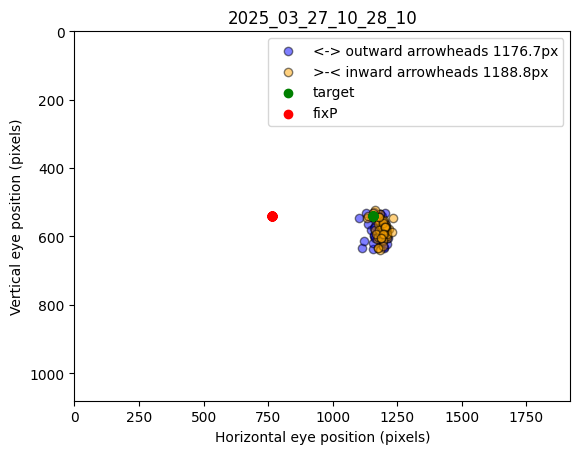

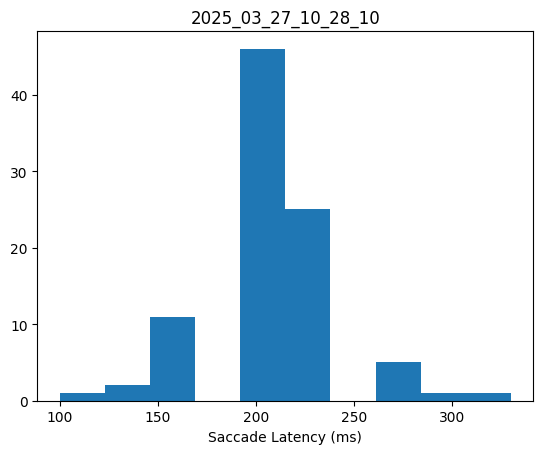

In [25]:
from deepeye_analysis_package.getFixations import extract_fixations

# Initialize an empty list to hold the processed dataframes
output_dfs = []
summary_dfs = []

# Get all folder names from the data directory
folder_names = [name for name in os.listdir(path_to_data) if os.path.isdir(os.path.join(path_to_data, name))]

# Process each participant's data
for fn in folder_names:
    # Check if _record_extra.csv exists, if not use _record.csv
    path_to_file = os.path.join(path_to_data, fn, f'{fn}_mullerlyer_record_extra.csv')
    if not os.path.exists(path_to_file):
        path_to_file = os.path.join(path_to_data, fn, f'{fn}_mullerlyer_record.csv')

        print(f'Extracting fixations for participant {fn}...')

        try:
            df = pd.read_csv(path_to_file, on_bad_lines='skip')
            df = extract_fixations(df, path_to_file)
            df = df.drop_duplicates(subset=['user_pred_px_x', 'user_pred_px_y'], ignore_index=True)  # Ensure unique coordinates (sometimes webcam is stuck)
            
        except FileNotFoundError:
            print(f'File does not exist: {path_to_file}')
            continue    
    else: 
        try:
            df = pd.read_csv(path_to_file, on_bad_lines='skip')
            df = df.drop_duplicates(subset=['user_pred_px_x', 'user_pred_px_y'], ignore_index=True)  # Ensure unique coordinates (sometimes webcam is stuck)

        except FileNotFoundError:
            print(f'File does not exist: {path_to_file}')
            continue

    print(f'Processing participant {fn}...')
    # Filter data to only include rows where the target was presented
    df1 = df[df['event'] == 'target_on'].copy()

    # Add subject ID to the dataframe
    df1['deepeye_id'] = fn

    ### Convert critical columns to numeric values if they are not ###
    df1['FixXPos'] = pd.to_numeric(df1['FixXPos'], errors='coerce')
    df1['FixYPos'] = pd.to_numeric(df1['FixYPos'], errors='coerce')
    df1['targetX'] = pd.to_numeric(df1['targetX'], errors='coerce')
    df1['fixationStimY'] = pd.to_numeric(df1['fixationStimY'], errors='coerce')
    df1['fixationStimX'] = pd.to_numeric(df1['fixationStimX'], errors='coerce')
    df1['resX'] = pd.to_numeric(df1['resX'], errors='coerce')
    df1['resY'] = pd.to_numeric(df1['resY'], errors='coerce')
    df1['scrW_cm'] = pd.to_numeric(df1['scrW_cm'], errors='coerce')
    df1['PrevFixXPos'] = pd.to_numeric(df1['PrevFixXPos'], errors='coerce')
    df1['PrevFixYPos'] = pd.to_numeric(df1['PrevFixYPos'], errors='coerce')
    df1['PrevFixSampTime'] = pd.to_numeric(df1['PrevFixSampTime'], errors='coerce')
    df1['DistFromPrevFix'] = pd.to_numeric(df1['DistFromPrevFix'], errors='coerce')

    # Get saccade endpoint data and latency
    summary_df = getSaccades(df1, fn, plot=True)  
    summary_dfs.append(summary_df)  

    # Accumulate the processed dataframe for this participant
    output_dfs.append(df1)

# Concatenate all participants' data into one DataFrame
if output_dfs:
    output_df = pd.concat(output_dfs, ignore_index=True)
    output_file = os.path.join(path_to_analysis, 'allSubjects_ML.csv')
    output_df.to_csv(output_file, index=False)
    print(f'Combined data saved to {output_file}')
else:
    print('No data was processed.')

# Concatenate all participants' summary data into one DataFrame
if summary_dfs:
    summary_df = pd.concat(summary_dfs, ignore_index=True)
    summary_file = os.path.join(path_to_analysis, 'allSubjects_ML_summary.csv')
    summary_df.to_csv(summary_file, index=False)
    print(f'Combined summary data saved to {summary_file}')
else:
    print('No summary data was processed.')


### Filter out subjects with too few datapoints in outward or inward condition

In [26]:
# Count the number of data points per 'deepeye_id' and 'condition'
count_df = summary_df.groupby(['condition', 'deepeye_id']).size().reset_index(name='counts')
print(count_df)

# Set a threshold for the minimum number of data points per condition
min_data_points = 5  # Adjust this threshold as needed

# Filter out deepeye_ids that don't meet the minimum number of data points
invalid_deepeye_ids = count_df[count_df['counts'] <= min_data_points]['deepeye_id'].unique()

print(f'\nExcluded subjects based on too few valid trials: {invalid_deepeye_ids}')

# Filter the original DataFrame to exclude the invalid deepeye_ids
filtered_summary_df = summary_df[~summary_df['deepeye_id'].isin(invalid_deepeye_ids)]

           condition           deepeye_id  counts
0   arrowHeadsInward  2025_03_27_10_28_10      45
1  arrowHeadsOutward  2025_03_27_10_28_10      47

Excluded subjects based on too few valid trials: []


### Analyze Illusion Size Per Participant

condition           deepeye_id  arrowHeadsInward  arrowHeadsOutward  \
0          2025_03_27_10_28_10       1188.844194        1176.681846   

condition  IllusionSize  IllusionSize_percent  
0             12.162347              3.118551  
T-test: t=nan, p=nan
Mean Illusion_%: 3.1185505517430263
Mean line_length_cm: 10.231481481481481
Number of participants: 1


c:\Users\aby600\Documents\GitHub\DeepEye_analyze\deepeye_analyze\lib\site-packages\scipy\stats\_stats_py.py:1114: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
c:\Users\aby600\Documents\GitHub\DeepEye_analyze\deepeye_analyze\lib\site-packages\scipy\stats\_stats_py.py:1114: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


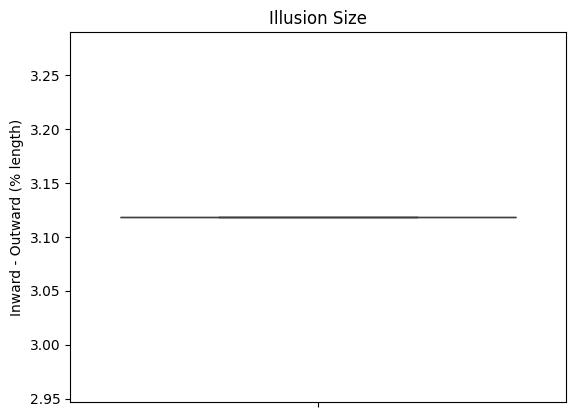

In [27]:
# Summary statistics for the saccade endpoints
illusSize_df = filtered_summary_df.groupby(['condition', 'deepeye_id', 'pp_id',
                                        'scale_px_per_cm', 'line_length_cm',
                                        'NormtargetX', 'NormfixationStimX',
                                        'fixationStimY'])[['NormFixXPos', 'FixYPos']].mean().reset_index()
# print(illusSize_df)
# Extract constant per participant
df_a = filtered_summary_df.groupby(['deepeye_id', 'scale_px_per_cm',
                                    'line_length_cm', 'NormtargetX',
                                    'NormfixationStimX','fixationStimY'])[['NormFixXPos']].mean().reset_index()
# print(df_a)
a = df_a.scale_px_per_cm
b = df_a.line_length_cm
# c = df_a.NormtargetX
# d = df_a.fixationStimY
# e = df_a.NormfixationStimX

# Pivot the DataFrame to have conditions as columns
illusSize_df_FixXPos = illusSize_df.pivot(index='deepeye_id', columns='condition', values='NormFixXPos').reset_index()
illusSize_df_FixXPos['IllusionSize'] = illusSize_df_FixXPos.arrowHeadsInward - illusSize_df_FixXPos.arrowHeadsOutward
illusSize_df_FixXPos['IllusionSize_percent'] = illusSize_df_FixXPos['IllusionSize']/a / b * 100.0

# Drop subjects with NaN values
illusSize_df_FixXPos = illusSize_df_FixXPos.dropna()
print(illusSize_df_FixXPos)

# Plot the illusion size
plt.figure()
plt.title('Illusion Size')
plt.ylabel('Inward - Outward (% length)')
sns.boxplot(illusSize_df_FixXPos.IllusionSize_percent)

# T-test
from scipy.stats import ttest_rel
t, p = ttest_rel(illusSize_df_FixXPos.arrowHeadsInward, illusSize_df_FixXPos.arrowHeadsOutward)
print(f'T-test: t={t}, p={p}')

print(f'Mean Illusion_%: {illusSize_df_FixXPos.IllusionSize_percent.mean()}')
print(f'Mean line_length_cm: {b.mean()}')
print(f'Number of participants: {illusSize_df_FixXPos.shape[0]}')

### Analyze Saccade Latency per subject

condition           deepeye_id  arrowHeadsInward  arrowHeadsOutward  \
0          2025_03_27_10_28_10        210.428889         202.819149   

condition  IllusionLatencyDiff  
0                      7.60974  
T-test: t=nan, p=nan
Mean Illusion Latency Inward: 210.42888888887828
Mean Illusion Latency Outward: 202.81914893616403
Mean Illusion Latency Diff: 7.60973995271425
Number of participants: 1


c:\Users\aby600\Documents\GitHub\DeepEye_analyze\deepeye_analyze\lib\site-packages\scipy\stats\_stats_py.py:1114: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
c:\Users\aby600\Documents\GitHub\DeepEye_analyze\deepeye_analyze\lib\site-packages\scipy\stats\_stats_py.py:1114: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


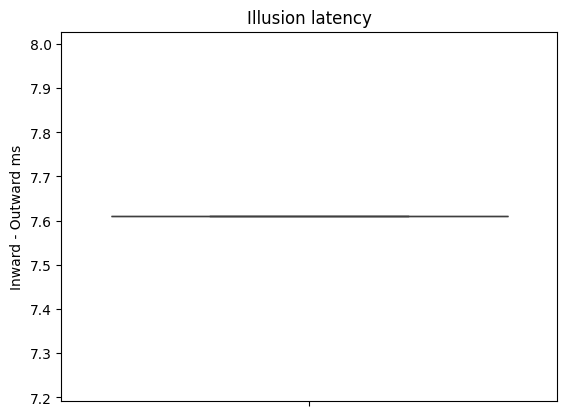

In [28]:
# Summary statistics for the saccade latency
illusLatency_df = filtered_summary_df.groupby(['condition', 'deepeye_id'])[['SaccLat']].mean().reset_index()

# Pivot the DataFrame to have conditions as columns
illusLatency_df = illusLatency_df.pivot(index='deepeye_id', columns='condition', values='SaccLat').reset_index()
illusLatency_df['IllusionLatencyDiff'] = illusLatency_df.arrowHeadsInward - illusLatency_df.arrowHeadsOutward
print(illusLatency_df)

# Plot the illusion latency
plt.figure()
plt.title('Illusion latency')
plt.ylabel('Inward - Outward ms')
sns.boxplot(illusLatency_df.IllusionLatencyDiff)

# T-test
from scipy.stats import ttest_rel
t, p = ttest_rel(illusLatency_df.arrowHeadsInward, illusLatency_df.arrowHeadsOutward)
print(f'T-test: t={t}, p={p}')
print(f'Mean Illusion Latency Inward: {illusLatency_df.arrowHeadsInward.mean()}')
print(f'Mean Illusion Latency Outward: {illusLatency_df.arrowHeadsOutward.mean()}')
print(f'Mean Illusion Latency Diff: {illusLatency_df.IllusionLatencyDiff.mean()}')
print(f'Number of participants: {illusLatency_df.shape[0]}')


### Saccade Latency For all subjects together, for outward and inward arrows

Mean outward latency: 202.81914893616403
Mean inward latency: 210.42888888887828


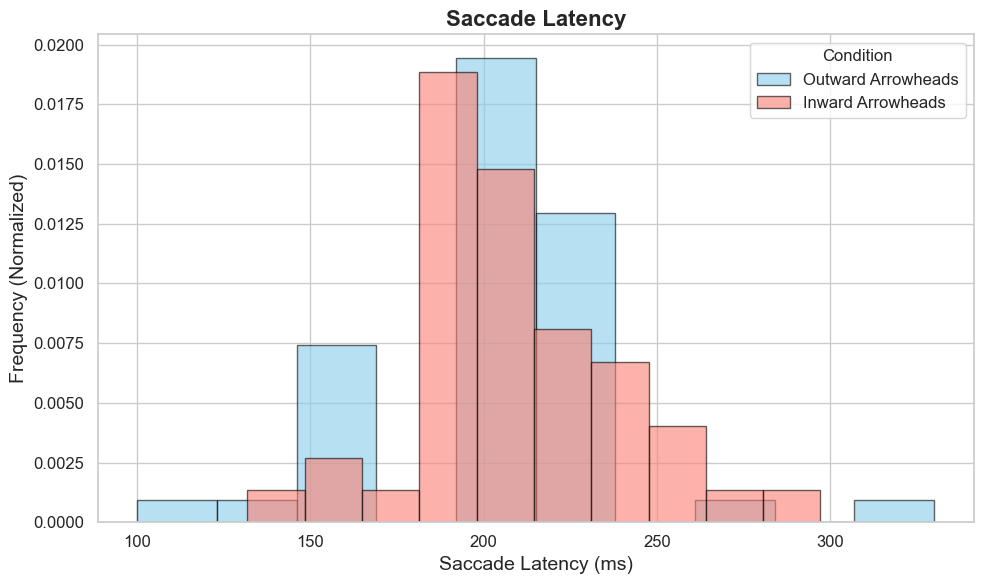

In [29]:
# Plot histograms with normalization
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

plt.title('Saccade Latency', fontsize=16, fontweight='bold')

outward = filtered_summary_df.SaccLat[summary_df.condition == 'arrowHeadsOutward']
inward = filtered_summary_df.SaccLat[summary_df.condition == 'arrowHeadsInward']

print(f'Mean outward latency: {outward.mean()}')
print(f'Mean inward latency: {inward.mean()}')

plt.hist(outward,  alpha=0.6, bins=10, label='Outward Arrowheads', density=True, color='skyblue', edgecolor='black')
plt.hist(inward,  alpha=0.6, bins=10, label='Inward Arrowheads', density=True, color='salmon', edgecolor='black')

plt.legend(title='Condition', fontsize=12)
plt.xlabel('Saccade Latency (ms)', fontsize=14)
plt.ylabel('Frequency (Normalized)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()